In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print ("Libraries imported successfully")


Libraries imported successfully


In [ ]:
import pandas as pd

df = pd.read_csv('/content/retail_sales_dataset_abi.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully!
Shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
# Basic information about the dataset

print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Number of rows and columns:
(1000, 9)

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

Missing values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Cat

In [ ]:
# Statistical summary

df.describe(include='all')


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000,1000,1000.00000,1000,1000.000000,1000.000000,1000.000000
unique,NaN,345,1000,2,NaN,3,NaN,NaN,NaN
top,NaN,2023-05-16,CUST1000,Female,NaN,Clothing,NaN,NaN,NaN
freq,NaN,11,1,510,NaN,351,NaN,NaN,NaN
mean,500.500000,NaN,NaN,NaN,41.39200,NaN,2.514000,179.890000,456.000000
std,288.819436,NaN,NaN,NaN,13.68143,NaN,1.132734,189.681356,559.997632
min,1.000000,NaN,NaN,NaN,18.00000,NaN,1.000000,25.000000,25.000000
25%,250.750000,NaN,NaN,NaN,29.00000,NaN,1.000000,30.000000,60.000000
50%,500.500000,NaN,NaN,NaN,42.00000,NaN,3.000000,50.000000,135.000000
75%,750.250000,NaN,NaN,NaN,53.00000,NaN,4.000000,300.000000,900.000000


In [ ]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Missing values in each column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Total missing values:
0

Number of duplicate rows:
0


In [ ]:
# Display the data types
print("Data types:")
print(df.dtypes)


Data types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [ ]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

print("Date column converted successfully!")
print(df['Date'].dtype)


Date column converted successfully!
datetime64[ns]


In [ ]:
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [ ]:
# Descriptive statistics for numerical columns

df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [ ]:
# Basic categorical analysis

print("Gender distribution:")
print(df['Gender'].value_counts())

print("\nProduct Category distribution:")
print(df['Product Category'].value_counts())

Gender distribution:
Gender
Female    510
Male      490
Name: count, dtype: int64

Product Category distribution:
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


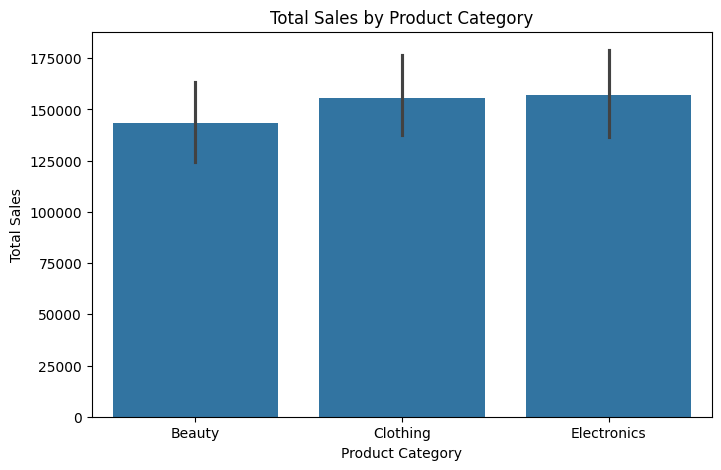

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Product Category',
    y='Total Amount',
    estimator='sum'
)

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.show()

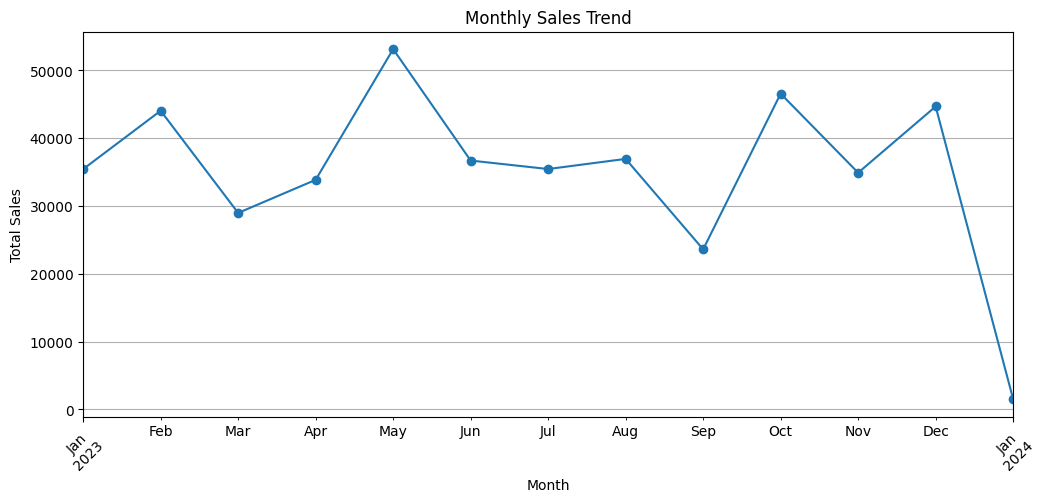

In [ ]:
# @title Default title text
# Monthly sales trend

monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Total Amount'].sum()

plt.figure(figsize=(12, 5))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Observation: Monthly sales fluctuate over time, showing changes in customer purchasing activity across different months.

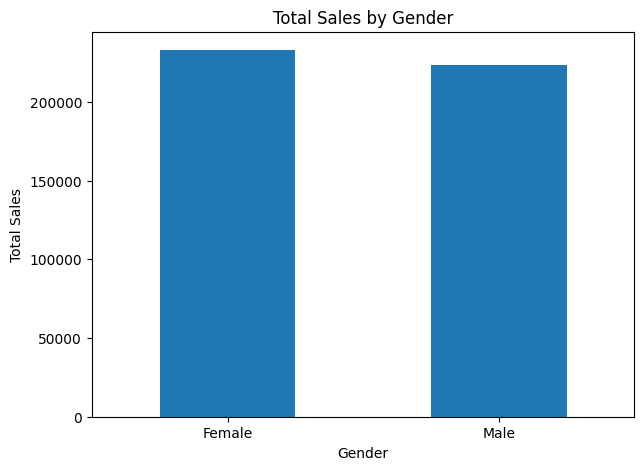

In [ ]:
# Total sales by gender

gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(7, 5))

gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

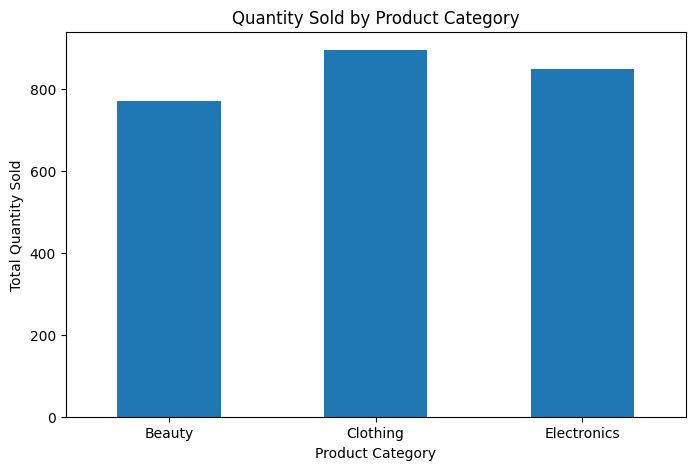

In [ ]:
# Total quantity sold by product category

category_quantity = df.groupby(
    'Product Category'
)['Quantity'].sum()

plt.figure(figsize=(8, 5))

category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=0)
plt.show()

Observation: Product categories contribute differently to total revenue and quantity sold. Higher-performing categories can be prioritized for inventory and promotional planning.

In [ ]:
# Create age groups

bins = [0, 18, 30, 45, 60, 100]
labels = ['Under 18', '18-30', '31-45', '46-60', '60+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

print(df['Age Group'].value_counts().sort_index())

Age Group
Under 18     21
18-30       252
31-45       303
46-60       331
60+          93
Name: count, dtype: int64


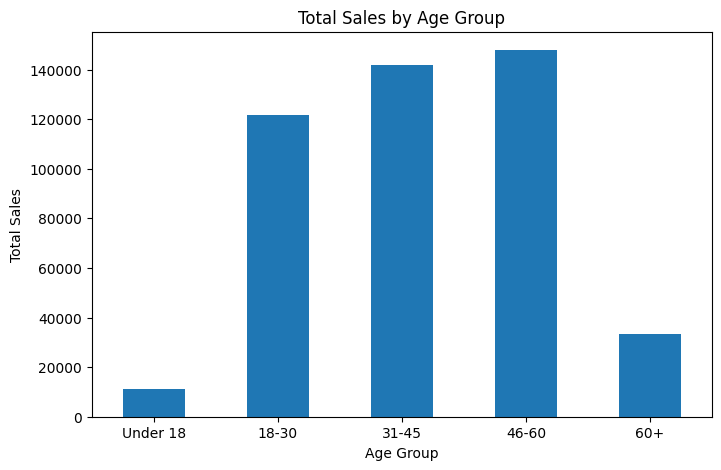

In [ ]:
# Sales by age group

age_sales = df.groupby(
    'Age Group', observed=False
)['Total Amount'].sum()

plt.figure(figsize=(8, 5))

age_sales.plot(kind='bar')

plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

Observation: Customer activity varies across age groups. Identifying the stronger age groups can help businesses target marketing campaigns more effectively.

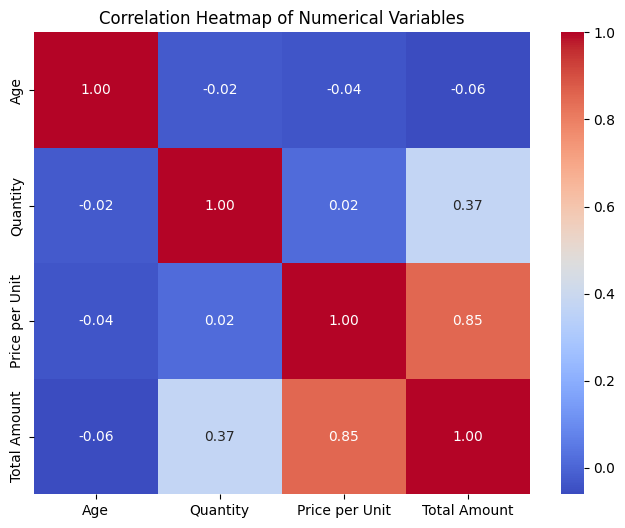

In [ ]:
# Correlation heatmap

numeric_columns = [
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

Observation: The correlation matrix shows the relationships between numerical variables such as age, quantity, price per unit, and total amount.

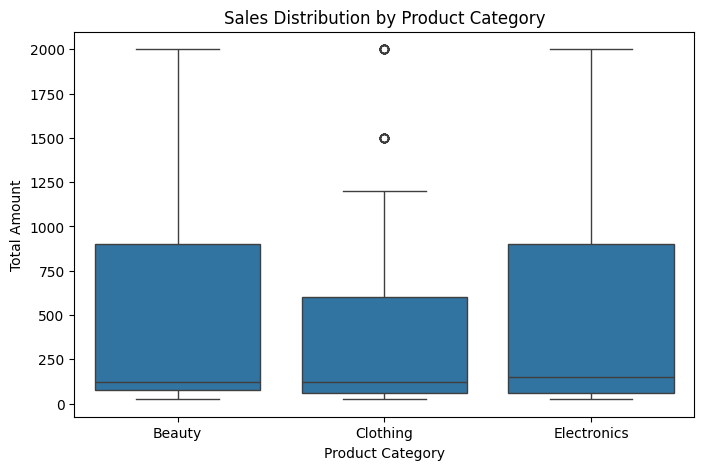

In [ ]:
# Sales distribution by product category

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Product Category',
    y='Total Amount'
)

plt.title('Sales Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.show()

Observation:Observation: The box plot shows the distribution and variation of transaction amounts across product categories and helps identify potential outliers.

In [ ]:
# Key business insights from the dataset

print("========== KEY INSIGHTS ==========\n")

# 1. Best-selling product category by revenue
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
print("1. Sales by Product Category:")
print(category_sales)

print("\nBest-selling category:",
      category_sales.idxmax(),
      "with total sales of", category_sales.max())

# 2. Sales by gender
gender_sales = df.groupby('Gender')['Total Amount'].sum().sort_values(ascending=False)
print("\n2. Sales by Gender:")
print(gender_sales)

print("\nHighest-sales gender:",
      gender_sales.idxmax(),
      "with total sales of", gender_sales.max())

# 3. Sales by age group
age_sales = df.groupby('Age Group', observed=False)['Total Amount'].sum().sort_values(ascending=False)
print("\n3. Sales by Age Group:")
print(age_sales)

print("\nHighest-sales age group:",
      age_sales.idxmax(),
      "with total sales of", age_sales.max())

# 4. Most frequently purchased category
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
print("\n4. Quantity Sold by Category:")
print(category_quantity)

print("\nHighest quantity category:",
      category_quantity.idxmax(),
      "with quantity sold of", category_quantity.max())

# 5. Overall statistics
print("\n5. Overall Statistics:")
print("Total Revenue:", df['Total Amount'].sum())
print("Average Transaction Value:", round(df['Total Amount'].mean(), 2))
print("Total Quantity Sold:", df['Quantity'].sum())
print("Average Customer Age:", round(df['Age'].mean(), 2))

========== KEY INSIGHTS ==========

1. Sales by Product Category:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

Best-selling category: Electronics with total sales of 156905

2. Sales by Gender:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

Highest-sales gender: Female with total sales of 232840

3. Sales by Age Group:
Age Group
46-60       147875
31-45       141955
18-30       121730
60+          33225
Under 18     11215
Name: Total Amount, dtype: int64

Highest-sales age group: 46-60 with total sales of 147875

4. Quantity Sold by Category:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

Highest quantity category: Clothing with quantity sold of 894

5. Overall Statistics:
Total Revenue: 456000
Average Transaction Value: 456.0
Total Quantity Sold: 2514
Average Customer Age: 41.39


In [ ]:
# Conclusion

print("""
CONCLUSION

The retail sales dataset was analyzed using Python, Pandas,
Matplotlib and Seaborn. Exploratory Data Analysis was performed
to understand sales trends, customer demographics, product
categories and relationships between numerical variables.

The analysis included descriptive statistics, monthly sales trends,
gender-wise sales, age-group analysis, product-category analysis,
a correlation heatmap and sales distribution.

The insights obtained from the analysis can help businesses
understand customer purchasing patterns, identify high-performing
product categories and make better data-driven decisions.
""")


CONCLUSION

The retail sales dataset was analyzed using Python, Pandas,
Matplotlib and Seaborn. Exploratory Data Analysis was performed
to understand sales trends, customer demographics, product
categories and relationships between numerical variables.

The analysis included descriptive statistics, monthly sales trends,
gender-wise sales, age-group analysis, product-category analysis,
a correlation heatmap and sales distribution.

The insights obtained from the analysis can help businesses
understand customer purchasing patterns, identify high-performing
product categories and make better data-driven decisions.



In [ ]:
readme_content = """
# OIBSIP - Retail Sales Exploratory Data Analysis

## Project Overview

This project performs Exploratory Data Analysis (EDA) on a retail sales dataset.
The analysis focuses on understanding sales patterns, customer demographics,
product categories, and relationships between numerical variables.

## Objective

The main objectives of this project are:

- Understand the structure of the retail sales data.
- Perform data inspection and cleaning.
- Calculate descriptive statistics.
- Analyze monthly sales trends.
- Analyze sales by gender and age group.
- Analyze product category performance.
- Study correlations between numerical variables.
- Generate meaningful business insights and recommendations.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

## Dataset

The dataset contains retail transaction information including:

- Transaction ID
- Date
- Customer ID
- Gender
- Age
- Product Category
- Quantity
- Price per Unit
- Total Amount

## Analysis Performed

1. Dataset inspection
2. Missing-value analysis
3. Duplicate-value analysis
4. Data type conversion
5. Descriptive statistics
6. Monthly sales trend analysis
7. Gender-wise sales analysis
8. Product category analysis
9. Age-group analysis
10. Correlation heatmap
11. Sales distribution analysis

## Conclusion

The analysis provides insights into customer purchasing behavior,
product performance, sales trends, and relationships among numerical
variables. These insights can support data-driven business decisions
and improve understanding of retail sales performance.
"""

with open("README.md", "w") as f:
    f.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [7]:
# ==========================================
# COMPLETE DESCRIPTIVE STATISTICS
# ==========================================

import pandas as pd

# Load the dataset again
df = pd.read_csv('/content/retail_sales_dataset_abi.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

# Numerical columns
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

print("\n========== DESCRIPTIVE STATISTICS ==========")

for col in numeric_cols:
    print("\n" + col)
    print("-" * 30)
    print("Mean   :", round(df[col].mean(), 2))
    print("Median :", round(df[col].median(), 2))
    print("Mode   :", round(df[col].mode().iloc[0], 2))
    print("Std Dev:", round(df[col].std(), 2))

Dataset loaded successfully!
Shape: (1000, 9)

========== DESCRIPTIVE STATISTICS ==========

Age
------------------------------
Mean   : 41.39
Median : 42.0
Mode   : 43
Std Dev: 13.68

Quantity
------------------------------
Mean   : 2.51
Median : 3.0
Mode   : 4
Std Dev: 1.13

Price per Unit
------------------------------
Mean   : 179.89
Median : 50.0
Mode   : 50
Std Dev: 189.68

Total Amount
------------------------------
Mean   : 456.0
Median : 135.0
Mode   : 50
Std Dev: 560.0


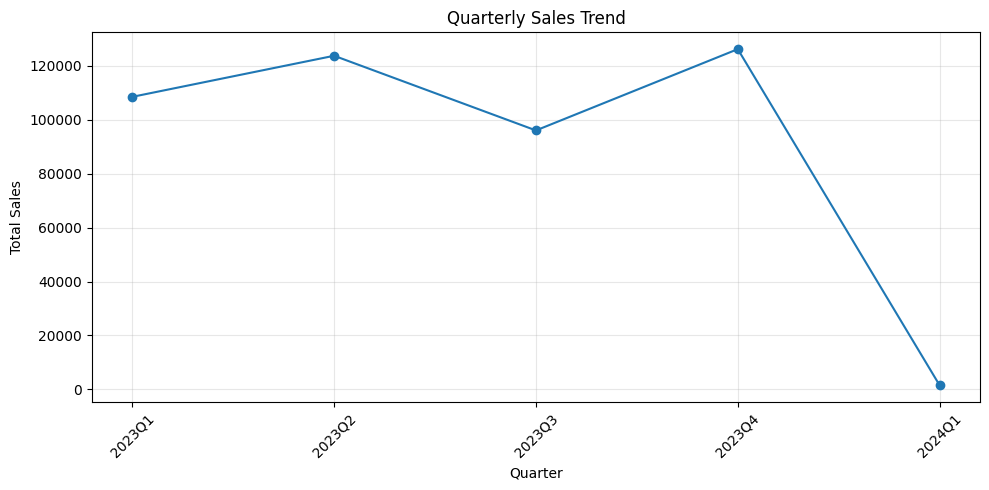

In [9]:
# ==========================================
# QUARTERLY SALES TREND
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/retail_sales_dataset_abi.csv')

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Calculate quarterly sales
quarterly_sales = df.groupby(
    df['Date'].dt.to_period('Q')
)['Total Amount'].sum()

# Plot quarterly sales
plt.figure(figsize=(10, 5))
plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Observation: Quarterly sales show differences in revenue across quarters, helping identify periods with relatively higher or lower sales performance.

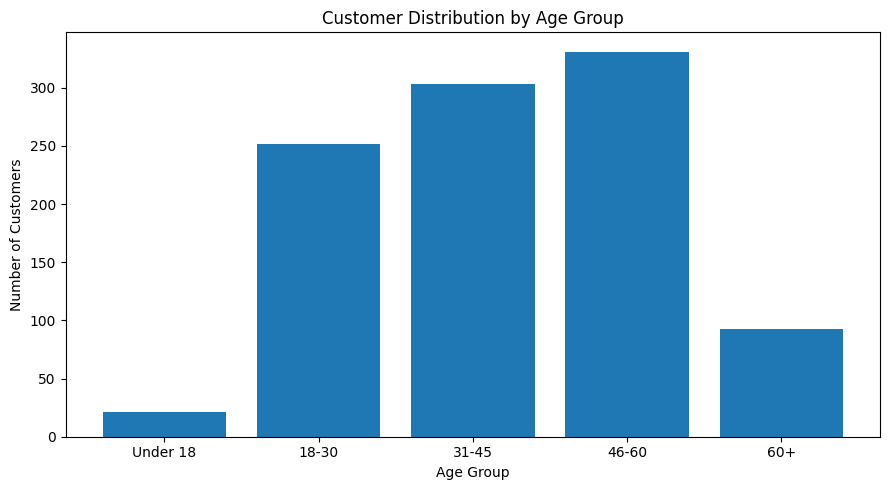

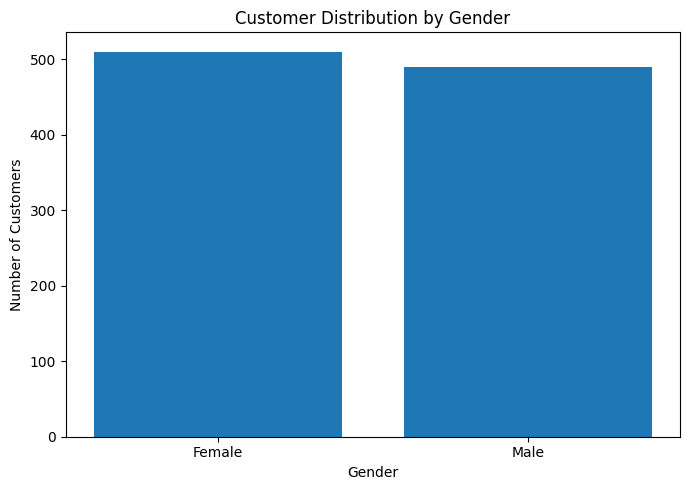

========== CUSTOMER DEMOGRAPHICS ==========

Age Group Distribution:
Age Group
Under 18     21
18-30       252
31-45       303
46-60       331
60+          93
Name: count, dtype: int64

Gender Distribution:
Gender
Female    510
Male      490
Name: count, dtype: int64


In [10]:
# ==========================================
# CUSTOMER DEMOGRAPHICS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/retail_sales_dataset_abi.csv')

# -------------------------------
# AGE GROUP ANALYSIS
# -------------------------------

bins = [0, 18, 30, 45, 60, 100]
labels = ['Under 18', '18-30', '31-45', '46-60', '60+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

age_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(9, 5))
plt.bar(age_counts.index.astype(str), age_counts.values)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


# -------------------------------
# GENDER BREAKDOWN
# -------------------------------

gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(gender_counts.index, gender_counts.values)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


# -------------------------------
# PRINT RESULTS
# -------------------------------

print("========== CUSTOMER DEMOGRAPHICS ==========")

print("\nAge Group Distribution:")
print(age_counts)

print("\nGender Distribution:")
print(gender_counts)

Observation: The gender-wise analysis shows the distribution of customers and their contribution to sales, which can help understand the customer base..

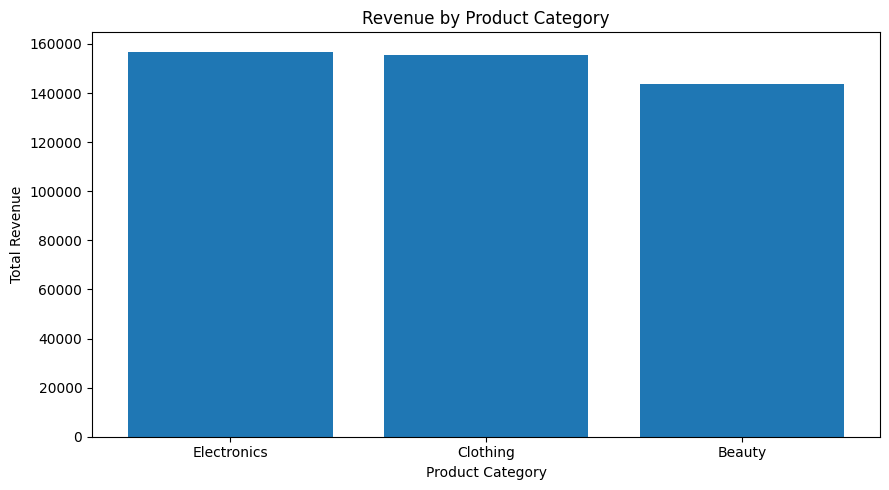

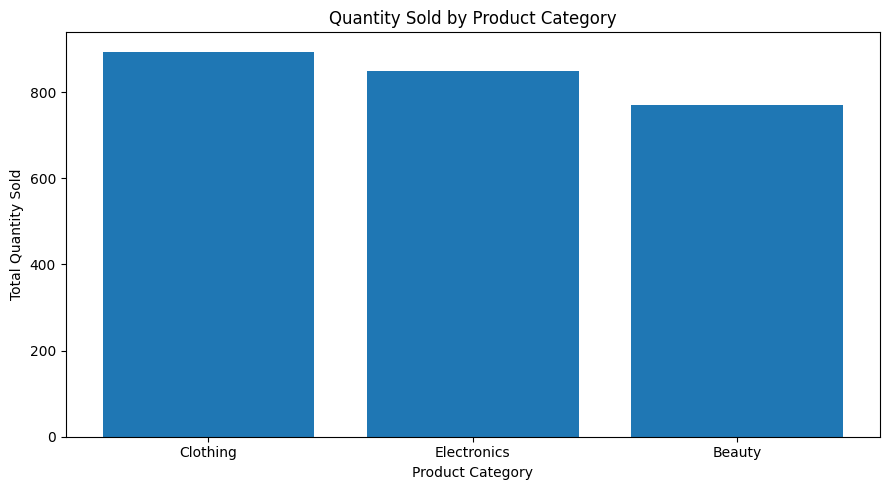

========== PRODUCT CATEGORY ANALYSIS ==========

Revenue by Product Category:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

Quantity Sold by Product Category:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


In [11]:
# ==========================================
# PRODUCT CATEGORY ANALYSIS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/retail_sales_dataset_abi.csv')

# -------------------------------
# SALES BY PRODUCT CATEGORY
# -------------------------------

category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(category_sales.index, category_sales.values)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()


# -------------------------------
# QUANTITY SOLD BY CATEGORY
# -------------------------------

category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(category_quantity.index, category_quantity.values)

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.tight_layout()
plt.show()


# -------------------------------
# PRINT RESULTS
# -------------------------------

print("========== PRODUCT CATEGORY ANALYSIS ==========")

print("\nRevenue by Product Category:")
print(category_sales)

print("\nQuantity Sold by Product Category:")
print(category_quantity)

ACTIONABLE BUSINESS RECOMMENDATIONS

1. Focus on high-performing product categories by allocating more inventory and promotional resources to categories generating higher revenue.

2. Use customer demographics for targeted marketing by designing campaigns according to the stronger age and gender segments.

3. Use monthly and quarterly sales trends to improve inventory planning and prepare for periods of higher demand.

4. Monitor transaction-value patterns to identify opportunities to increase average transaction value.

CONCLUSION

The retail sales dataset was analyzed using Python, Pandas, Matplotlib and Seaborn. The analysis included data inspection, descriptive statistics, monthly and quarterly sales trends, customer demographics, product category analysis, correlation analysis and sales distribution.

The results provide useful insights into customer purchasing patterns and category performance. These findings can support better inventory planning, customer targeting and promotional decisions.